In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlp_ensemble import process_csv

2025-12-09 05:24:01.271593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765257841.299548   51970 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765257841.308254   51970 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765257841.328311   51970 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765257841.328357   51970 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765257841.328360   51970 computation_placer.cc:177] computation placer alr

In [23]:
df1 = process_csv("regularized_const_01C_C_only_englacial_temp_amundsen_r005_geo_12_bed_class_updated_geo_cleaned.csv")
df2 = process_csv("regularized_const_01C_C_only_englacial_temp_amundsen_r005_geo_12_bed_class_updated_geo_2.csv")


In [14]:
df2[df2.isnull().any(axis=1)]

,theta,C,C_total,x,y,s11,s12,s21,s22,grad_h_1,...,gravity_disturbance,bed_class,invariant1,invariant2,mag_h,mag_s,mag_b,total_u_error,vel_mag,driving_stress
54293,0.0,13.673239,0.000000,-1629325.0,-300725.0,-0.309622,0.555673,-0.000436,0.046415,-0.050523,...,-38.848800,50835.243990,-0.263207,5.607459e-02,0.105086,0.011256,0.253863,549.124780,1574.984359,40.971865
54294,0.0,17.223486,0.000000,-1629325.0,-301175.0,-0.274323,0.547858,0.003354,0.033879,-0.058191,...,-38.772505,48512.930220,-0.240444,4.376606e-02,0.117812,0.012619,0.241259,536.334823,1305.381913,45.973045
54295,0.0,20.711820,0.000466,-1629325.0,-301625.0,-0.239588,0.539319,0.006755,0.021909,-0.066212,...,-38.699370,46242.259945,-0.217679,3.338726e-02,0.130466,0.013974,0.228899,523.641338,1041.890453,50.946952
54296,0.0,24.138240,0.009450,-1629325.0,-302075.0,-0.205418,0.530053,0.009766,0.010505,-0.074586,...,-38.629396,44023.233167,-0.194913,2.482066e-02,0.143060,0.015323,0.216774,511.309652,787.414572,55.896125
54518,0.0,2.073496,0.000000,-1628875.0,-299375.0,-0.413885,0.562388,-0.037947,0.096633,-0.025552,...,-39.561666,53261.250311,-0.317251,9.964635e-02,0.057221,0.006129,0.281191,566.992455,2206.390824,22.186736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846047,0.0,1.070145,0.020050,-1356175.0,-705725.0,0.000431,-0.000226,0.000821,-0.000003,0.009572,...,-18.647082,-271.095192,0.000428,6.849923e-10,0.009948,0.002252,0.008225,NaN,22.106676,47.913672
846048,0.0,1.092926,0.020496,-1356175.0,-706175.0,0.000411,-0.000245,0.000787,-0.000038,0.008978,...,-16.350070,-176.481117,0.000373,-3.435511e-09,0.009903,0.002239,0.008152,NaN,21.938706,47.652811
846049,0.0,1.115216,0.020939,-1356175.0,-706625.0,0.000393,-0.000261,0.000750,-0.000075,0.008175,...,-14.174689,-109.227708,0.000319,-2.856538e-09,0.009733,0.002221,0.008025,NaN,21.770890,47.269489
847485,0.0,1.032160,0.019181,-1355725.0,-704825.0,0.000490,-0.000111,0.000819,0.000067,0.008677,...,-21.251999,-321.234187,0.000557,6.030864e-08,0.009267,0.001378,0.008836,NaN,22.150439,29.533490


In [16]:
df2.shape

(1530051, 39)

In [17]:
df2.isnull().sum().sum()

np.int64(40692)

In [18]:
df2.isnull().any()

theta                  False
C                      False
C_total                False
x                      False
y                      False
s11                    False
s12                    False
s21                    False
s22                    False
grad_h_1               False
grad_h_2               False
grad_s_1               False
grad_s_2               False
grad_b_1               False
grad_b_2               False
x_velocity             False
y_velocity             False
x_velocity_initial     False
y_velocity_initial     False
err_x                   True
err_y                   True
h                      False
s                      False
b                      False
mag_anomaly            False
boug_anomaly           False
heatflux                True
snow_accumulation      False
surface_air_temp       False
gravity_disturbance    False
bed_class              False
invariant1             False
invariant2             False
mag_h                  False
mag_s         

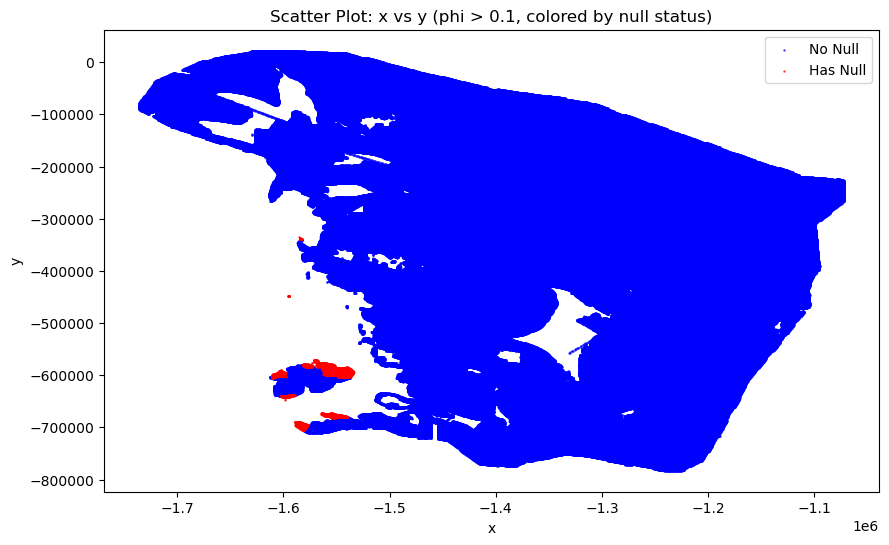

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Define threshold
threshold = 0.1

# Filter data where phi > threshold
df_filtered = df2[df2['phi'] > threshold]

# Create binary indicator for null values in the 'input' column
null_mask = df_filtered['heatflux'].isnull()

# Plot with separate colors for null vs non-null
df_not_null = df_filtered[~null_mask]
df_null = df_filtered[null_mask]

plt.figure(figsize=(10, 6))
plt.scatter(df_not_null['x'], df_not_null['y'], c='blue', label='No Null', alpha=0.6, s = 0.7)
plt.scatter(df_null['x'], df_null['y'], c='red', label='Has Null', alpha=0.6, s = 0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Scatter Plot: x vs y (phi > {threshold}, colored by null status)')
plt.legend()
plt.show()


In [2]:
import pandas as pd

# Load data
df_clean = pd.read_csv(
    "regularized_const_01C_C_only_englacial_temp_amundsen_r005_geo_12_bed_class_updated_geo_cleaned.csv",
    index_col=0
)
df_geo2 = pd.read_csv(
    "regularized_const_01C_C_only_englacial_temp_amundsen_r005_geo_12_bed_class_updated_geo_2.csv",
    index_col=0
)

# 1. Check x,y match exactly
x_match = (df_clean['x'].values == df_geo2['x'].values).all()
y_match = (df_clean['y'].values == df_geo2['y'].values).all()

print("x match:", x_match)
print("y match:", y_match)

if not (x_match and y_match):
    raise ValueError("x and y do NOT match — aborting replacement.")

# 2. Replace bed_class column in df_geo2
df_geo2['bed_class'] = df_clean['bed_class'].values

# Create binary indicator for null values in the 'input' column
null_mask = df_geo2['heatflux'].isnull()

# Plot with separate colors for null vs non-null
df_geo2_not_null = df_geo2[~null_mask]

# 3. Save corrected file
output_path = "regularized_const_01C_C_only_englacial_temp_amundsen_r005_geo_12_bed_class_updated_geo_2_fixed.csv"
df_geo2_not_null.to_csv(output_path)

print("Replacement complete. Saved to:", output_path)



x match: True
y match: True
Replacement complete. Saved to: regularized_const_01C_C_only_englacial_temp_amundsen_r005_geo_12_bed_class_updated_geo_2_fixed.csv


In [9]:
df_geo2['bed_class'].unique()

array([0, 2, 1, 3])

In [9]:
columns = ['s', 'b', 'h', 'mag_h', 'mag_s', 'mag_b', 'driving_stress', 'heatflux', 'surface_air_temp','gravity_disturbance', 'boug_anomaly', 'bed_class']
# Store continuous columns BEFORE one-hot encoding
continuous_columns = [col for col in columns if col != 'bed_class']

# One-hot encode bed_class column
df = pd.get_dummies(df, columns=['bed_class'], prefix='bed_class', drop_first=False, dtype=int)

In [11]:
df.columns

Index(['theta', 'C', 'C_total', 'x', 'y', 's11', 's12', 's21', 's22',
       'grad_h_1', 'grad_h_2', 'grad_s_1', 'grad_s_2', 'grad_b_1', 'grad_b_2',
       'x_velocity', 'y_velocity', 'x_velocity_initial', 'y_velocity_initial',
       'err_x', 'err_y', 'h', 's', 'b', 'mag_anomaly', 'boug_anomaly',
       'heatflux', 'snow_accumulation', 'surface_air_temp',
       'gravity_disturbance', 'invariant1', 'invariant2', 'mag_h', 'mag_s',
       'mag_b', 'total_u_error', 'vel_mag', 'driving_stress', 'bed_class_0',
       'bed_class_1', 'bed_class_2', 'bed_class_3'],
      dtype='object')

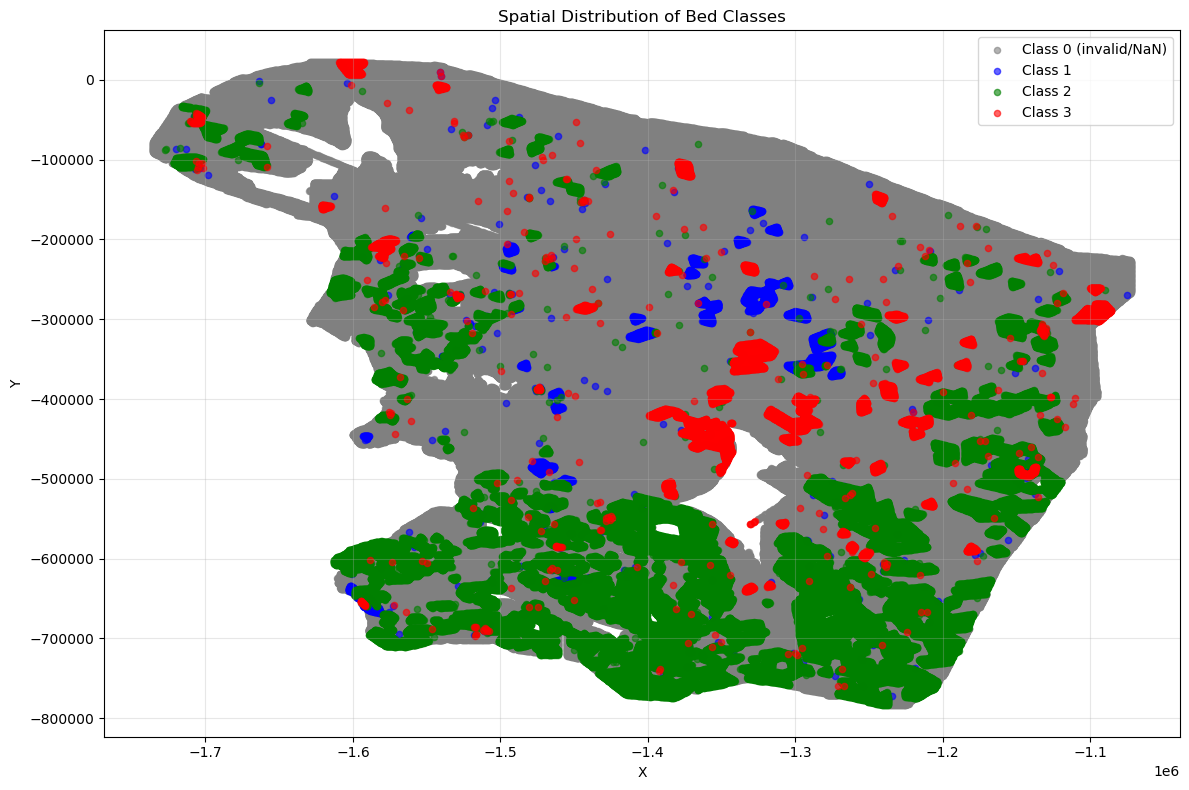

✓ Scatter plot saved as 'bed_class_scatter_plot.png'

=== Bed class distribution ===
bed_class
0    1276768
1       8791
2     224890
3      19602
Name: count, dtype: int64


In [12]:
# Clean bed_class
tolerance = 0.3

def clean_bed_class(value):
    if pd.isna(value):
        return 0
    for target in [1, 2, 3]:
        if abs(value - target) <= tolerance:
            return target
    return 0

df_cleaned = df.copy()
df_cleaned['bed_class'] = df['bed_class'].apply(clean_bed_class)

# Create scatter plot
plt.figure(figsize=(12, 8))

# Plot each bed_class with different colors
colors = {0: 'gray', 1: 'blue', 2: 'green', 3: 'red'}
labels = {0: 'Class 0 (invalid/NaN)', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3'}

for bed_class in sorted(df_cleaned['bed_class'].unique()):
    mask = df_cleaned['bed_class'] == bed_class
    plt.scatter(df_cleaned.loc[mask, 'x'], 
                df_cleaned.loc[mask, 'y'], 
                c=colors.get(bed_class, 'black'),
                label=labels.get(bed_class, f'Class {bed_class}'),
                alpha=0.6,
                s=20)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Spatial Distribution of Bed Classes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bed_class_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plot saved as 'bed_class_scatter_plot.png'")
print(f"\n=== Bed class distribution ===")
print(df_cleaned['bed_class'].value_counts().sort_index())


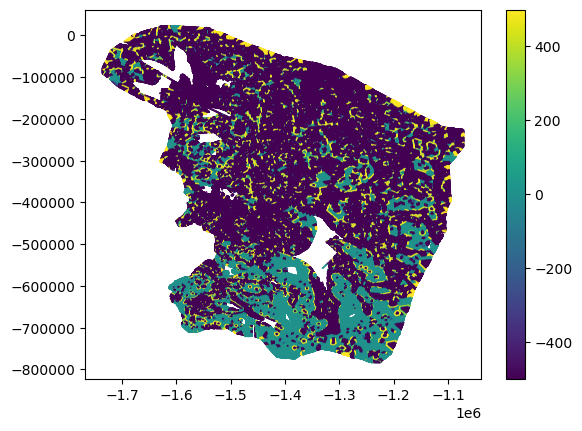

In [22]:
plt.scatter(df['x'], df['y'],c=  df['bed_class'], s = 0.1, vmin = -500, vmax = 500)
plt.colorbar()

In [1]:
import tensorflow as tf
print(tf.__version__)
print(tf.keras.__version__)

2025-11-09 05:19:56.892693: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-09 05:19:56.916689: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-09 05:19:56.924289: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-09 05:19:56.943804: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.17.0
3.10.0


In [2]:
import keras
print(keras.__version__)

3.10.0


In [3]:
df_pig = process_csv('regularized_const_01C_C_only_englacial_temp_pig_r005_geo_12.csv')
df_thwaites = process_csv('regularized_const_01C_C_only_englacial_temp_thwaites_r005_geo_12.csv')
df_dotson = process_csv('regularized_const_01C_C_only_englacial_temp_dotson_r005_geo_12.csv')

In [7]:
df = df_pig
value = 0.1  # Replace this with your desired threshold value
df = df[df['phi'] > value].reset_index(drop=True)  # Filter rows where 'phi' is greater than the threshold
print("pig shape:",df.shape)

pig shape: (192683, 39)


In [8]:
df = df_thwaites
value = 0.1  # Replace this with your desired threshold value
df = df[df['phi'] > value].reset_index(drop=True)  # Filter rows where 'phi' is greater than the threshold
print("thwaites shape:",df.shape)

thwaites shape: (834037, 39)


In [9]:
df = df_dotson
value = 0.1  # Replace this with your desired threshold value
df = df[df['phi'] > value].reset_index(drop=True)  # Filter rows where 'phi' is greater than the threshold
print("dotson shape:",df.shape)

dotson shape: (139432, 39)
